##### Stata setup init and data loading

In [9]:
from statasetup import *

In [11]:
%%stata
use "Datasets/asg1/PlannedEnv_Spain_India.dta", clear

##### Describing data
Getting a **general overview** of the content a categorical variable holds by using commands such as `codebook` or tabular form of the same overview `tab`. The argument `m` is providing the frequency/count of the missing values as well

In [12]:
%%stata
codebook country
tab country, m


. codebook country



-------------------------------------------------------------------------------
country                                                             (unlabeled)
-------------------------------------------------------------------------------

                  Type: Numeric (double)
                 Label: country2

                 Range: [1,2]                         Units: 1
         Unique values: 2                         Missing .: 1/400

            Tabulation: Freq.   Numeric  Label
                          199         1  Spain
                          200         2  India
                            1         .  

. tab country, m

    country |      Freq.     Percent        Cum.
------------+-----------------------------------
      Spain |        199       49.75       49.75
      India |        200       50.00       99.75
          . |          1        0.25      100.00
------------+-----------------------------------
      Total |        400      100.00

. 


##### **Counting** the number of missing values

In [41]:
%%stata
list id country individualism if individualism >=.
list count individualism if individualism >=.


. list id country individualism if individualism >=.

     +---------------------------+
     |   id   country   indivi~m |
     |---------------------------|
 49. | 1049     Spain         .a |
 79. | 1079     Spain          . |
     +---------------------------+

. list count individualism if individualism >=.

     +--------------------+
     | country   indivi~m |
     |--------------------|
 49. |   Spain         .a |
 79. |   Spain          . |
     +--------------------+

. 


##### **Geting an extensive overview** by using `sum var, d`. This can be used to test normality assumptions (**kurtosis**, **skewness**)

In [ ]:
%%stata
sktest individualism if country==1
sktest individualism if country== 2
by country: swilk individualism


. sktest individualism if country==1

Skewness and kurtosis tests for normality
                                                         ----- Joint test -----
    Variable |       Obs   Pr(skewness)   Pr(kurtosis)   Adj chi2(2)  Prob>chi2
-------------+-----------------------------------------------------------------
individual~m |       197         0.0000         0.0000         98.14     0.0000

. sktest individualism if country== 2

Skewness and kurtosis tests for normality
                                                         ----- Joint test -----
    Variable |       Obs   Pr(skewness)   Pr(kurtosis)   Adj chi2(2)  Prob>chi2
-------------+-----------------------------------------------------------------
individual~m |       200         0.0000         0.0001         37.69     0.0000

. 
. by country: swilk individualism

-------------------------------------------------------------------------------
-> country = Spain

                   Shapiro–Wilk W test for normal data

  

In [11]:
%%stata
sum individualism, d
sum individualism if country==1, detail
sum individualism if country!=1, detail
by country, sort: summarize indiv, d


. sum individualism, d

                        individualism
-------------------------------------------------------------
      Percentiles      Smallest
 1%          .09            .06
 5%          .17            .08
10%          .25            .08       Obs                 398
25%          .48            .09       Sum of wgt.         398

50%          .92                      Mean           1.011457
                        Largest       Std. dev.      .6555355
75%         1.38           3.46
90%         1.84           3.68       Variance       .4297268
95%         2.17           3.68       Skewness       1.227526
99%         3.46           4.54       Kurtosis       5.936006

. sum individualism if country==1, detail

                        individualism
-------------------------------------------------------------
      Percentiles      Smallest
 1%          .08            .06
 5%          .13            .08
10%          .17            .08       Obs                 197
25%       

##### Display things


. hist individualism, normal title("Individualism variable histogram") saving(b
> oth, replace)
(bin=19, start=.06, width=.23578947)


file both.gph saved

. hist individualism if country == 1, normal title("Spain overview through hist
> ") saving(spain, replace)
(bin=14, start=.06, width=.32)
(file spain.gph not found)
file spain.gph saved

. hist individualism if country == 2, normal title("Spain overview through hist
> ") saving(india, replace)
(bin=14, start=.24, width=.24571429)
(file india.gph not found)
file india.gph saved

. 


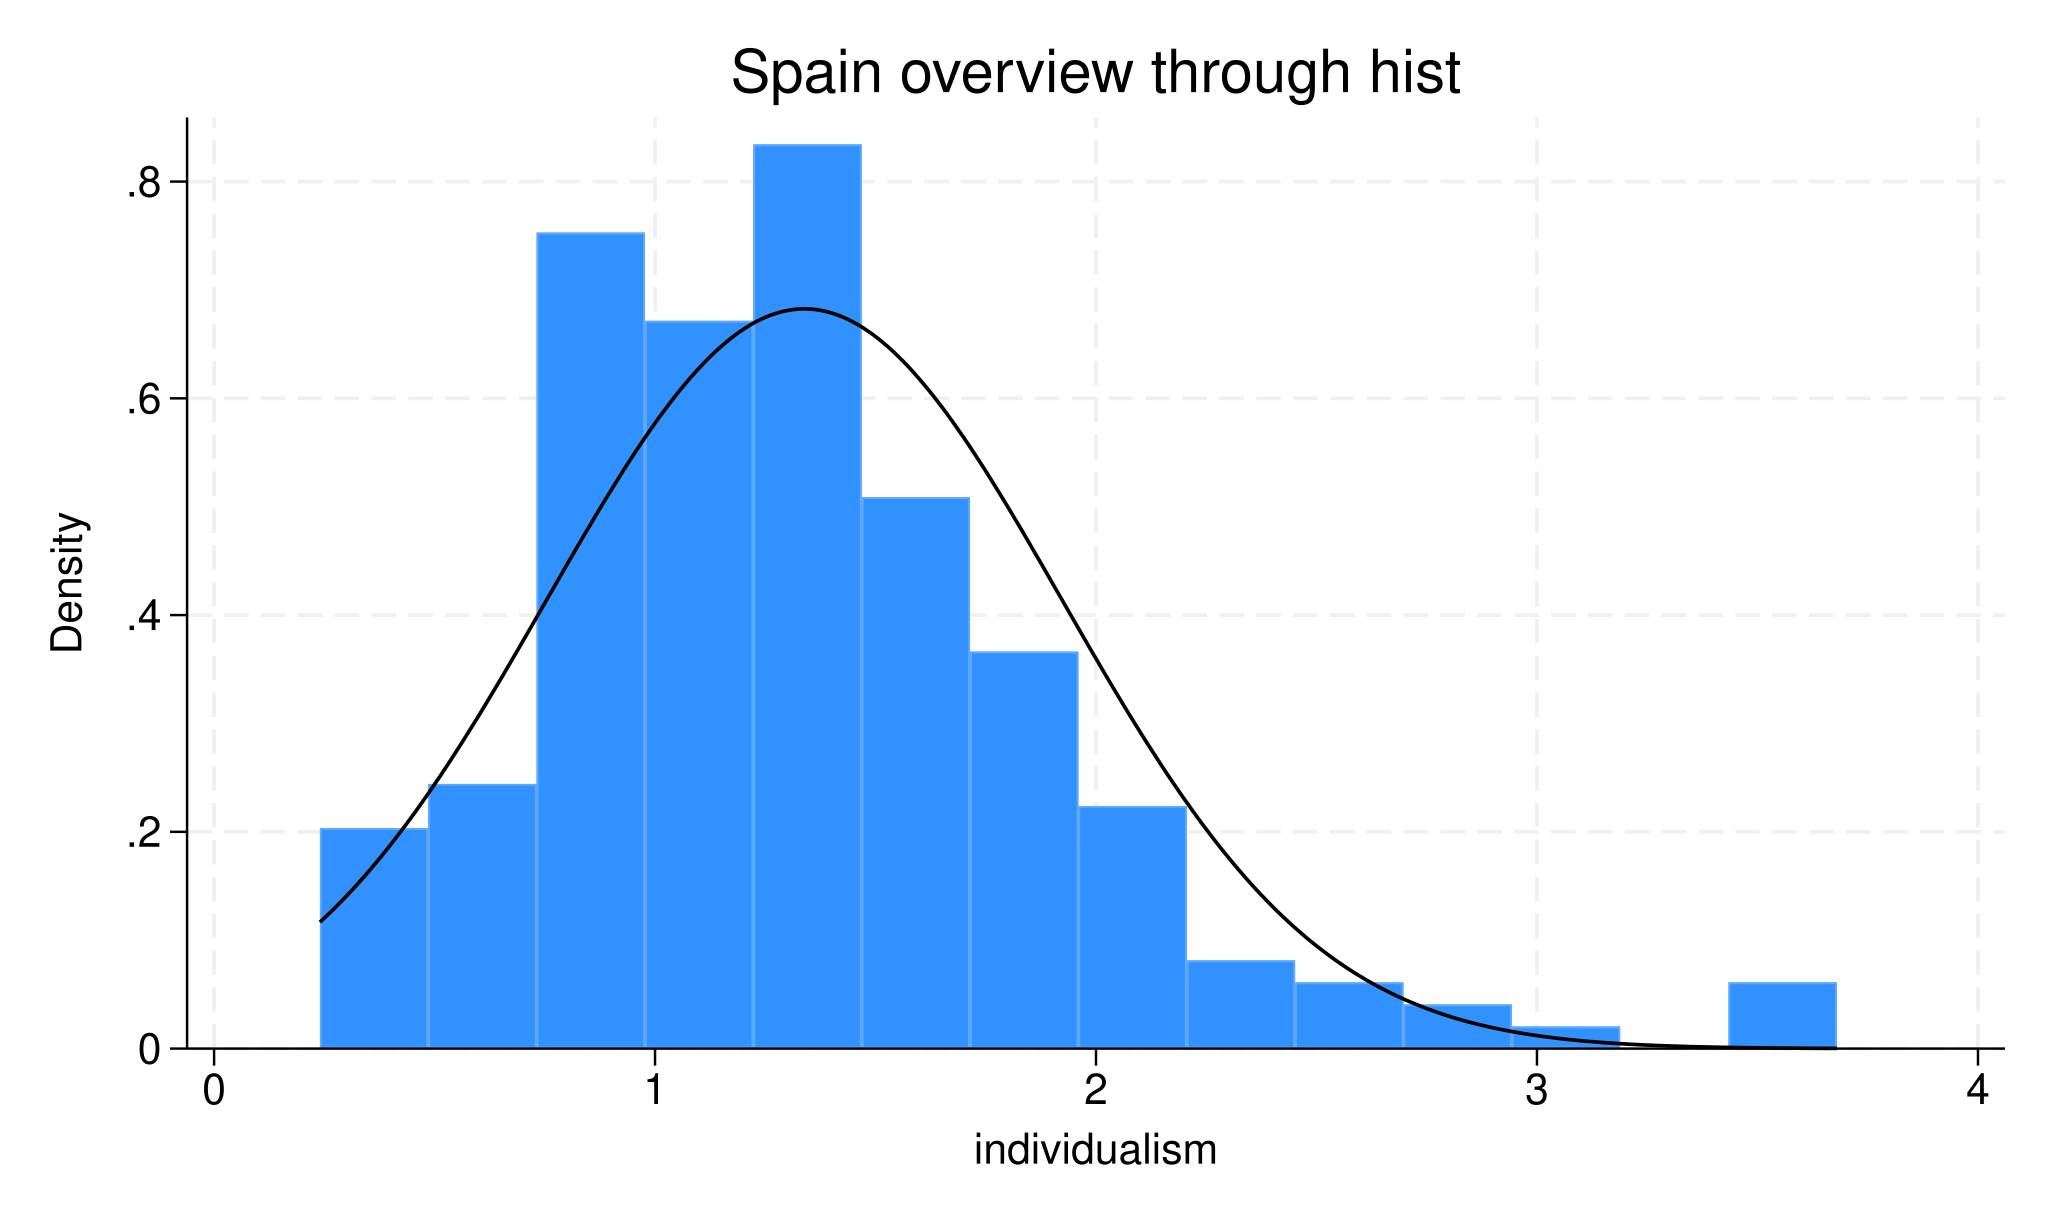

In [73]:
%%stata
hist individualism, normal title("Individualism variable histogram") saving(both, replace)
hist individualism if country == 1, normal title("Spain overview through hist") saving(spain, replace)
hist individualism if country == 2, normal title("Spain overview through hist") saving(india, replace)

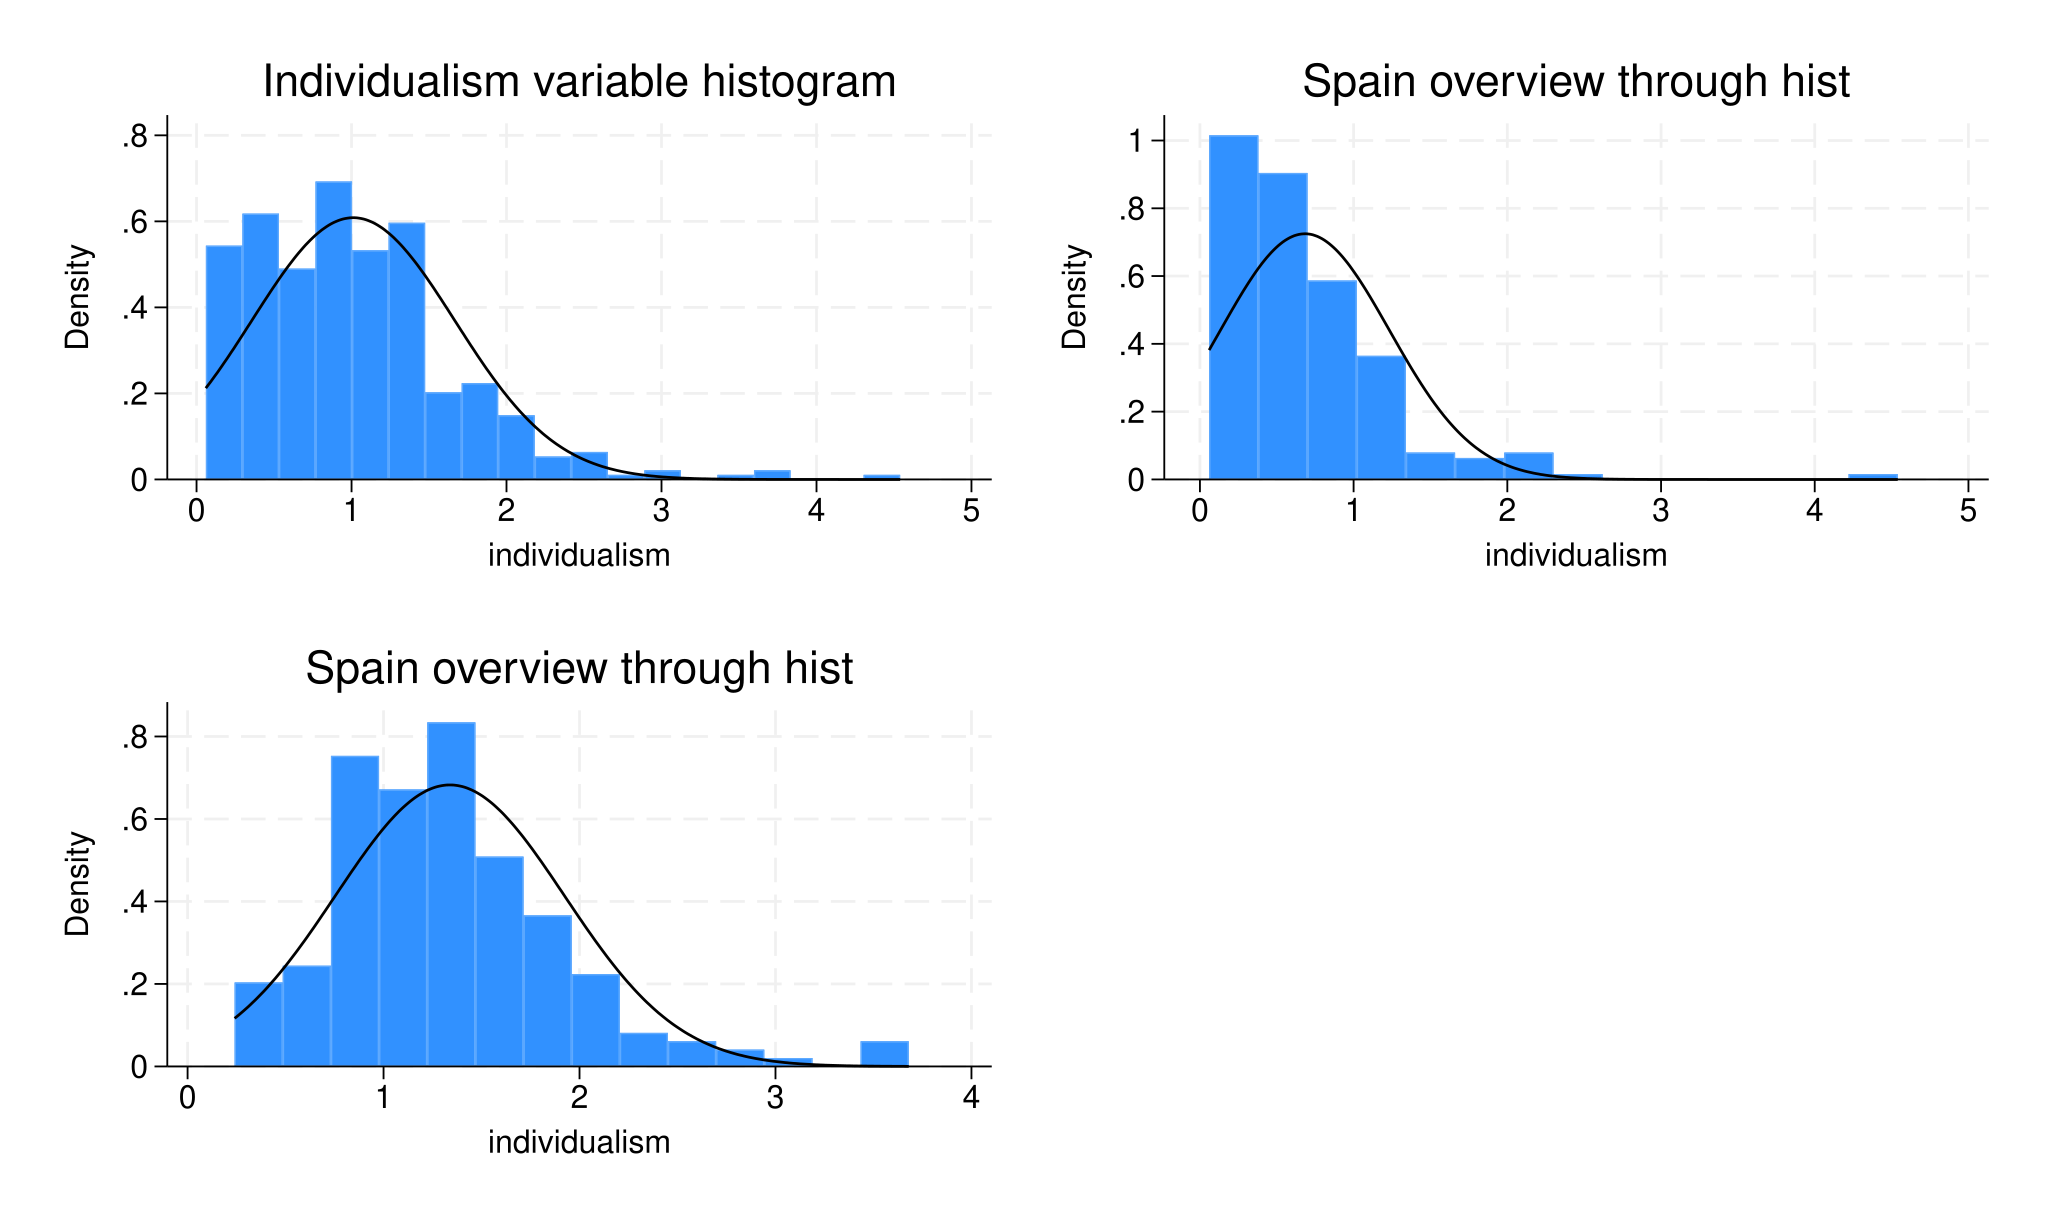

In [74]:
%%stata
gr combine both.gph spain.gph india.gph

##### Outliers...identification made by means of z-score calculation or influence basis
1. Unormalized box plots

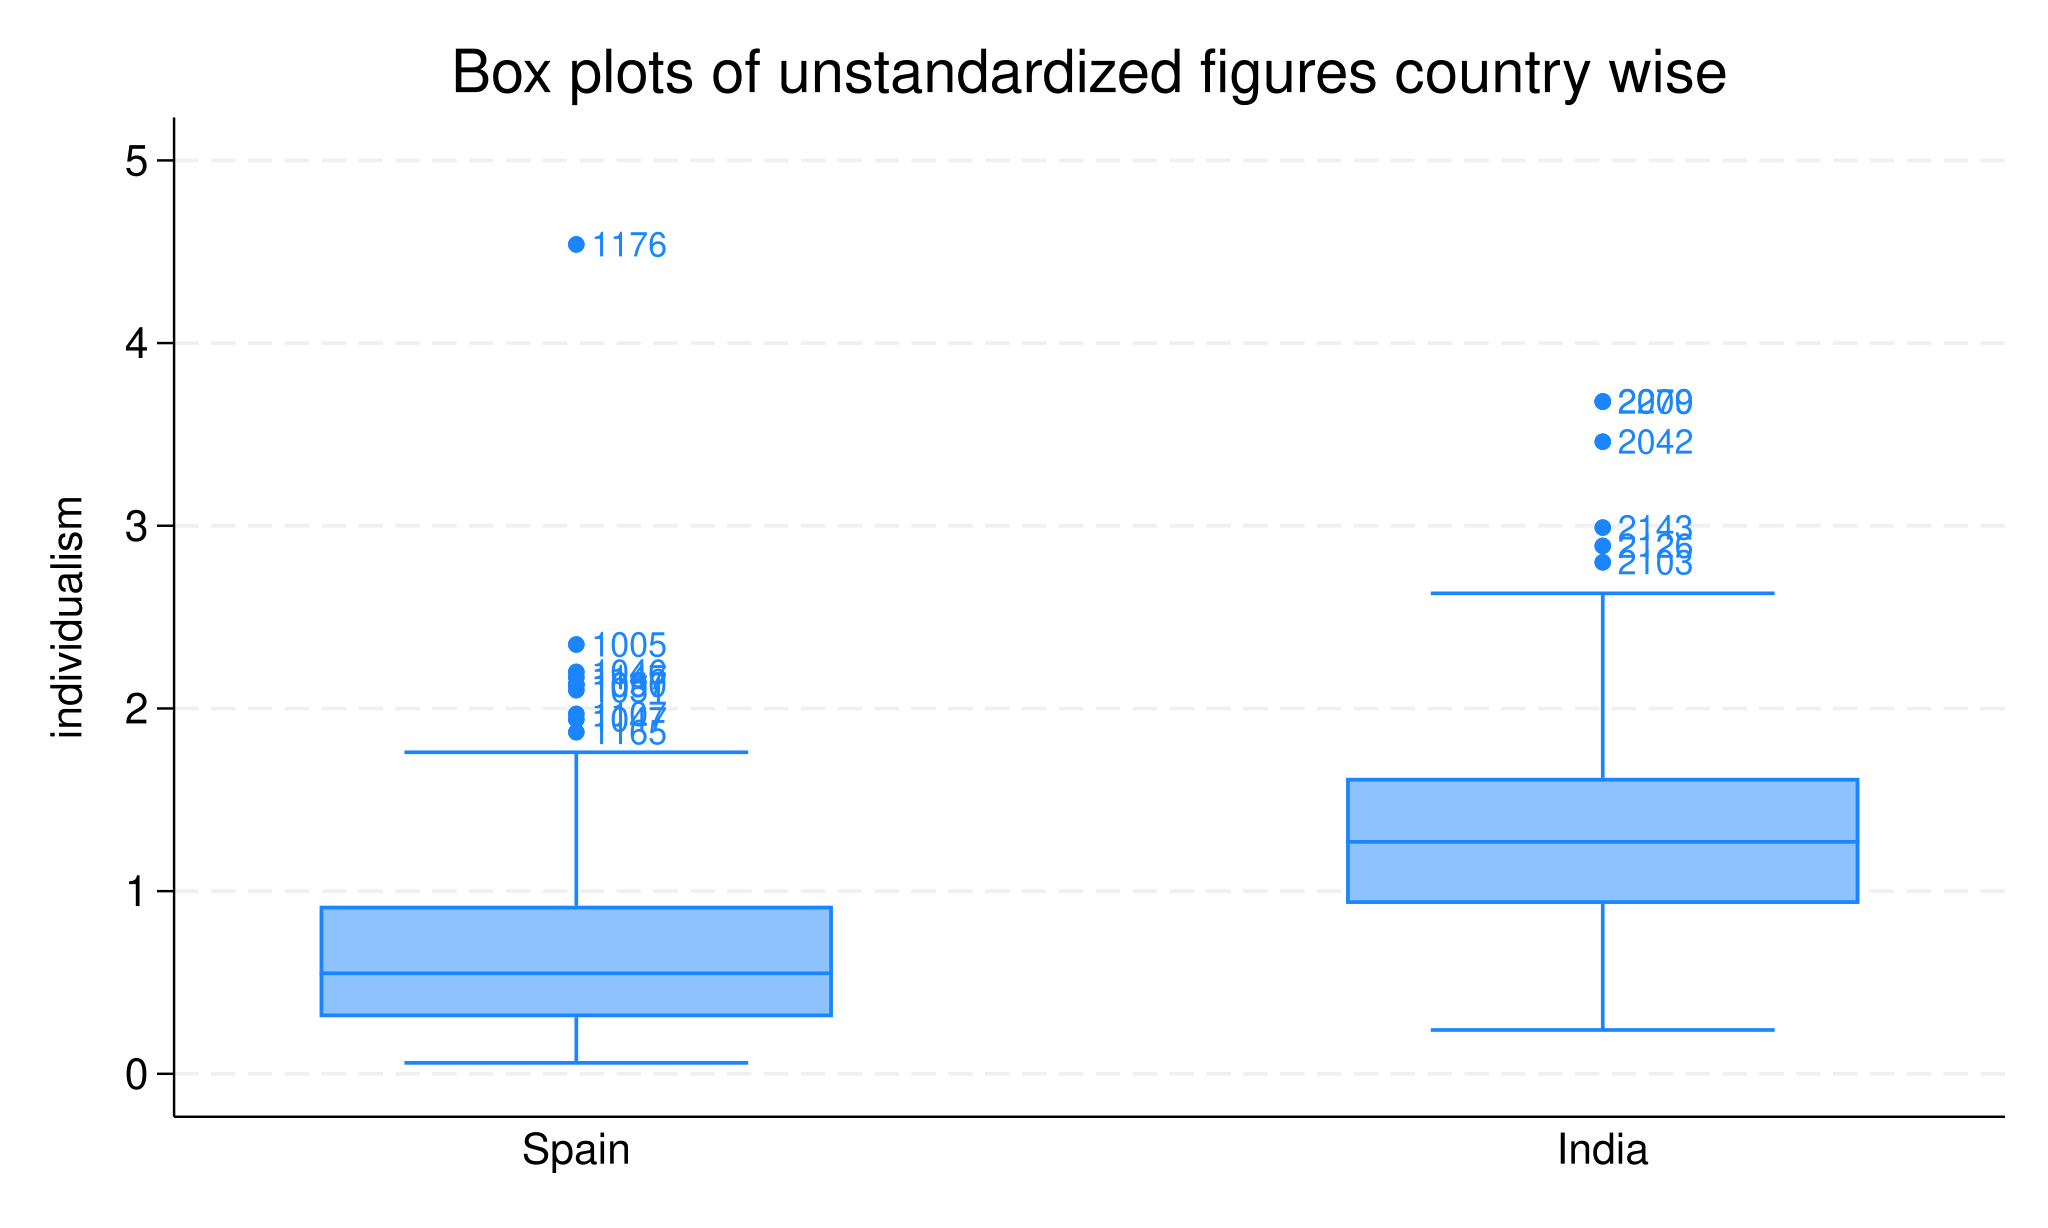

In [20]:
%%stata
graph box individualism, over(country) marker(1, mlabel(id)) title("Box plots of unstandardized figures country wise")

In [24]:
%%stata
drop p75 iqrange extr_values
bysort country, sort: egen p75 = pctile(indiv), p(75)
bysort country, sort: egen iqrange = iqr(indiv)
gen extr_values = p75+iqrange*4

list id country individualism if individualism <. & individualism >=extr_values


. drop p75 iqrange extr_values

. bysort country, sort: egen p75 = pctile(indiv), p(75)

. bysort country, sort: egen iqrange = iqr(indiv)

. gen extr_values = p75+iqrange*4

. 
. list id country individualism if individualism <. & individualism >=extr_valu
> es

     +---------------------------+
     |   id   country   indivi~m |
     |---------------------------|
137. | 1176     Spain       4.54 |
400. | 1178         .        .21 |
     +---------------------------+

. 


####
2. Comparison on output level of unstandardized and standardized groups

In [38]:
%%stata
drop z_india z_spain outliers
egen z_spain = std(individualism) if country ==1
egen z_india = std(individualism) if country ==2

list country id individualism if z_india <. & abs(z_india)>=4
list country id individualism if z_spain <. & abs(z_spain)>=4

gen outliers = 0
replace outliers =1 if abs(z_india)>=4 & z_india <.
replace outliers =1 if abs(z_spain)>=4 & z_spain <.


. drop z_india z_spain outliers

. egen z_spain = std(individualism) if country ==1
(203 missing values generated)

. egen z_india = std(individualism) if country ==2
(200 missing values generated)

. 
. list country id individualism if z_india <. & abs(z_india)>=4

     +---------------------------+
     | country     id   indivi~m |
     |---------------------------|
200. |   India   2200       3.68 |
309. |   India   2079       3.68 |
     +---------------------------+

. list country id individualism if z_spain <. & abs(z_spain)>=4

     +---------------------------+
     | country     id   indivi~m |
     |---------------------------|
137. |   Spain   1176       4.54 |
     +---------------------------+

. 
. gen outliers = 0

. replace outliers =1 if abs(z_india)>=4 & z_india <.
(2 real changes made)

. replace outliers =1 if abs(z_spain)>=4 & z_spain <.
(1 real change made)

. 


**Remove outliers** and do a normality test (e.g, check what the height of the central part (`kurtosis`) of the distribution is and its orientation/symmetry (`skewness`) and whether the variable has been drawn from a normal distribution (`shapiro-wilk`))

In [48]:
%%stata
sktest individualism if country ==1 & outliers~=1
sktest individualism if country ==2 & outliers~=1

bysort country: swilk individualism if outliers~=1 


. sktest individualism if country ==1 & outliers~=1

Skewness and kurtosis tests for normality
                                                         ----- Joint test -----
    Variable |       Obs   Pr(skewness)   Pr(kurtosis)   Adj chi2(2)  Prob>chi2
-------------+-----------------------------------------------------------------
individual~m |       196         0.0000         0.0011         36.93     0.0000

. sktest individualism if country ==2 & outliers~=1

Skewness and kurtosis tests for normality
                                                         ----- Joint test -----
    Variable |       Obs   Pr(skewness)   Pr(kurtosis)   Adj chi2(2)  Prob>chi2
-------------+-----------------------------------------------------------------
individual~m |       198         0.0000         0.0077         21.09     0.0000

. 
. bysort country: swilk individualism if outliers~=1 

-------------------------------------------------------------------------------
-> country = Spain

         

##### **Identify the transformation** that once applied to the target variable will make its underlying data appear normaly distributed
Note the p(chi2)
is the outcome of a normality test. To test the effectiveness of this transformation, I
did the shapiro-wilk test with all previously identified outliers included

In [64]:
%%stata
bysort country: ladder individualism if outliers~=1


-------------------------------------------------------------------------------
-> country = Spain

Transformation         Formula              chi2(2)  Prob > chi2
----------------------------------------------------------------
Cubic                  indivi~m^3            131.13        0.000
Square                 indivi~m^2             98.37        0.000
Identity               indivi~m               36.93        0.000
Square root            sqrt(indivi~m)          7.11        0.029
Log                    log(indivi~m)           5.44        0.066
1/(Square root)        1/sqrt(indivi~m)       35.23        0.000
Inverse                1/indivi~m             85.28        0.000
1/Square               1/(indivi~m^2)        170.91        0.000
1/Cubic                1/(indivi~m^3)        224.77        0.000

-------------------------------------------------------------------------------
-> country = India

Transformation         Formula              chi2(2)  Prob > chi2
------------------


. drop trans_indiv

. gen trans_indiv = sqrt(individualism)
(2 missing values generated)

. bysort country: swilk trans_indiv

-------------------------------------------------------------------------------
-> country = Spain

                   Shapiro–Wilk W test for normal data

    Variable |        Obs       W           V         z       Prob>z
-------------+------------------------------------------------------
 trans_indiv |        197    0.95687      6.350     4.250    0.00001

-------------------------------------------------------------------------------
-> country = India

                   Shapiro–Wilk W test for normal data

    Variable |        Obs       W           V         z       Prob>z
-------------+------------------------------------------------------
 trans_indiv |        200    0.98619      2.060     1.663    0.04815

-------------------------------------------------------------------------------
-> country = .

                   Shapiro–Wilk W test for norma

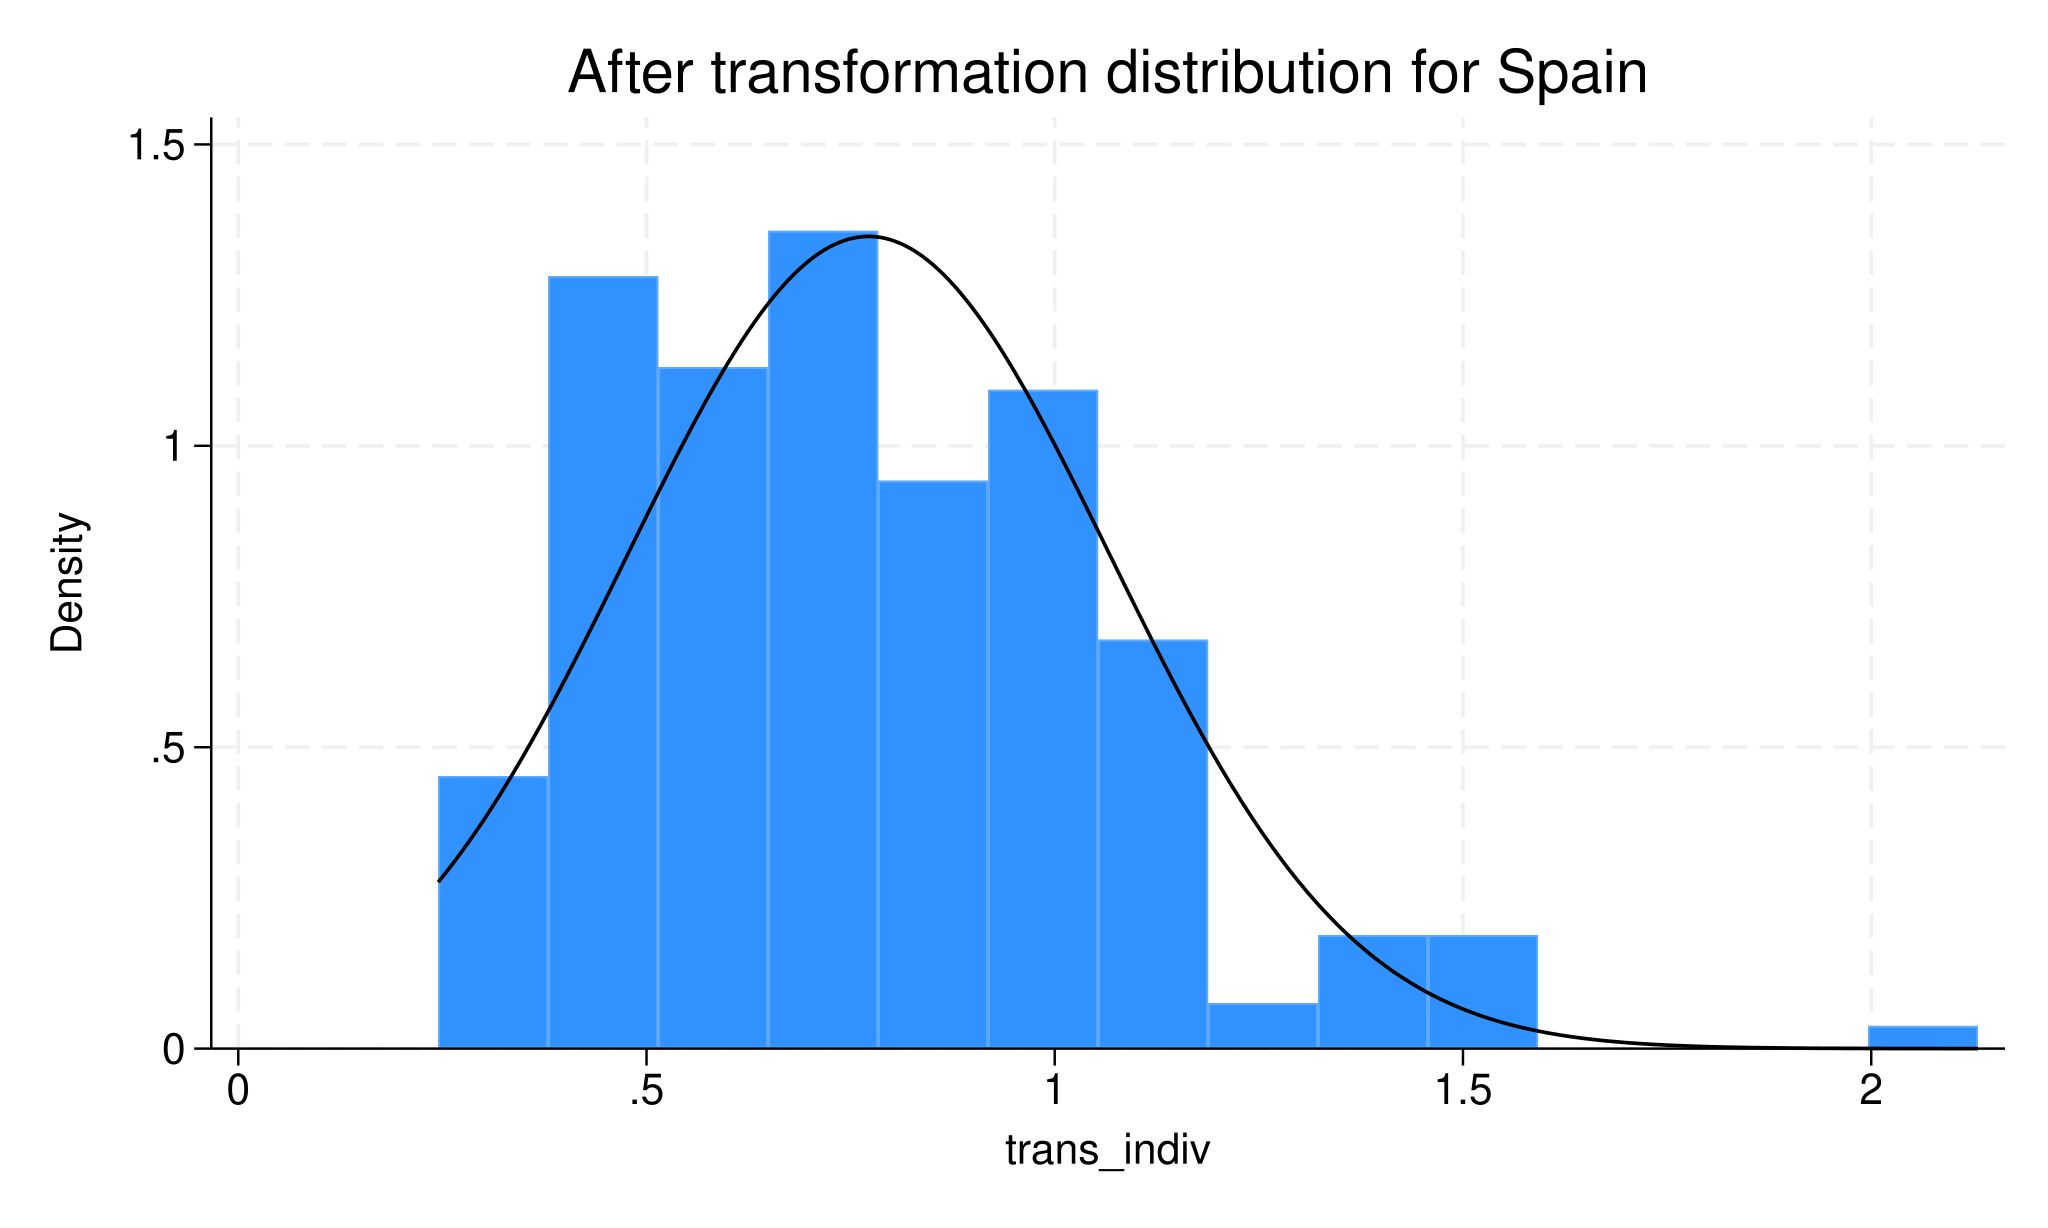

In [61]:
%%stata
drop trans_indiv
gen trans_indiv = sqrt(individualism)
bysort country: swilk trans_indiv


hist trans_indiv if country==1, normal title("After transformation distribution for Spain") 

(bin=14, start=.48989794, width=.10203105)


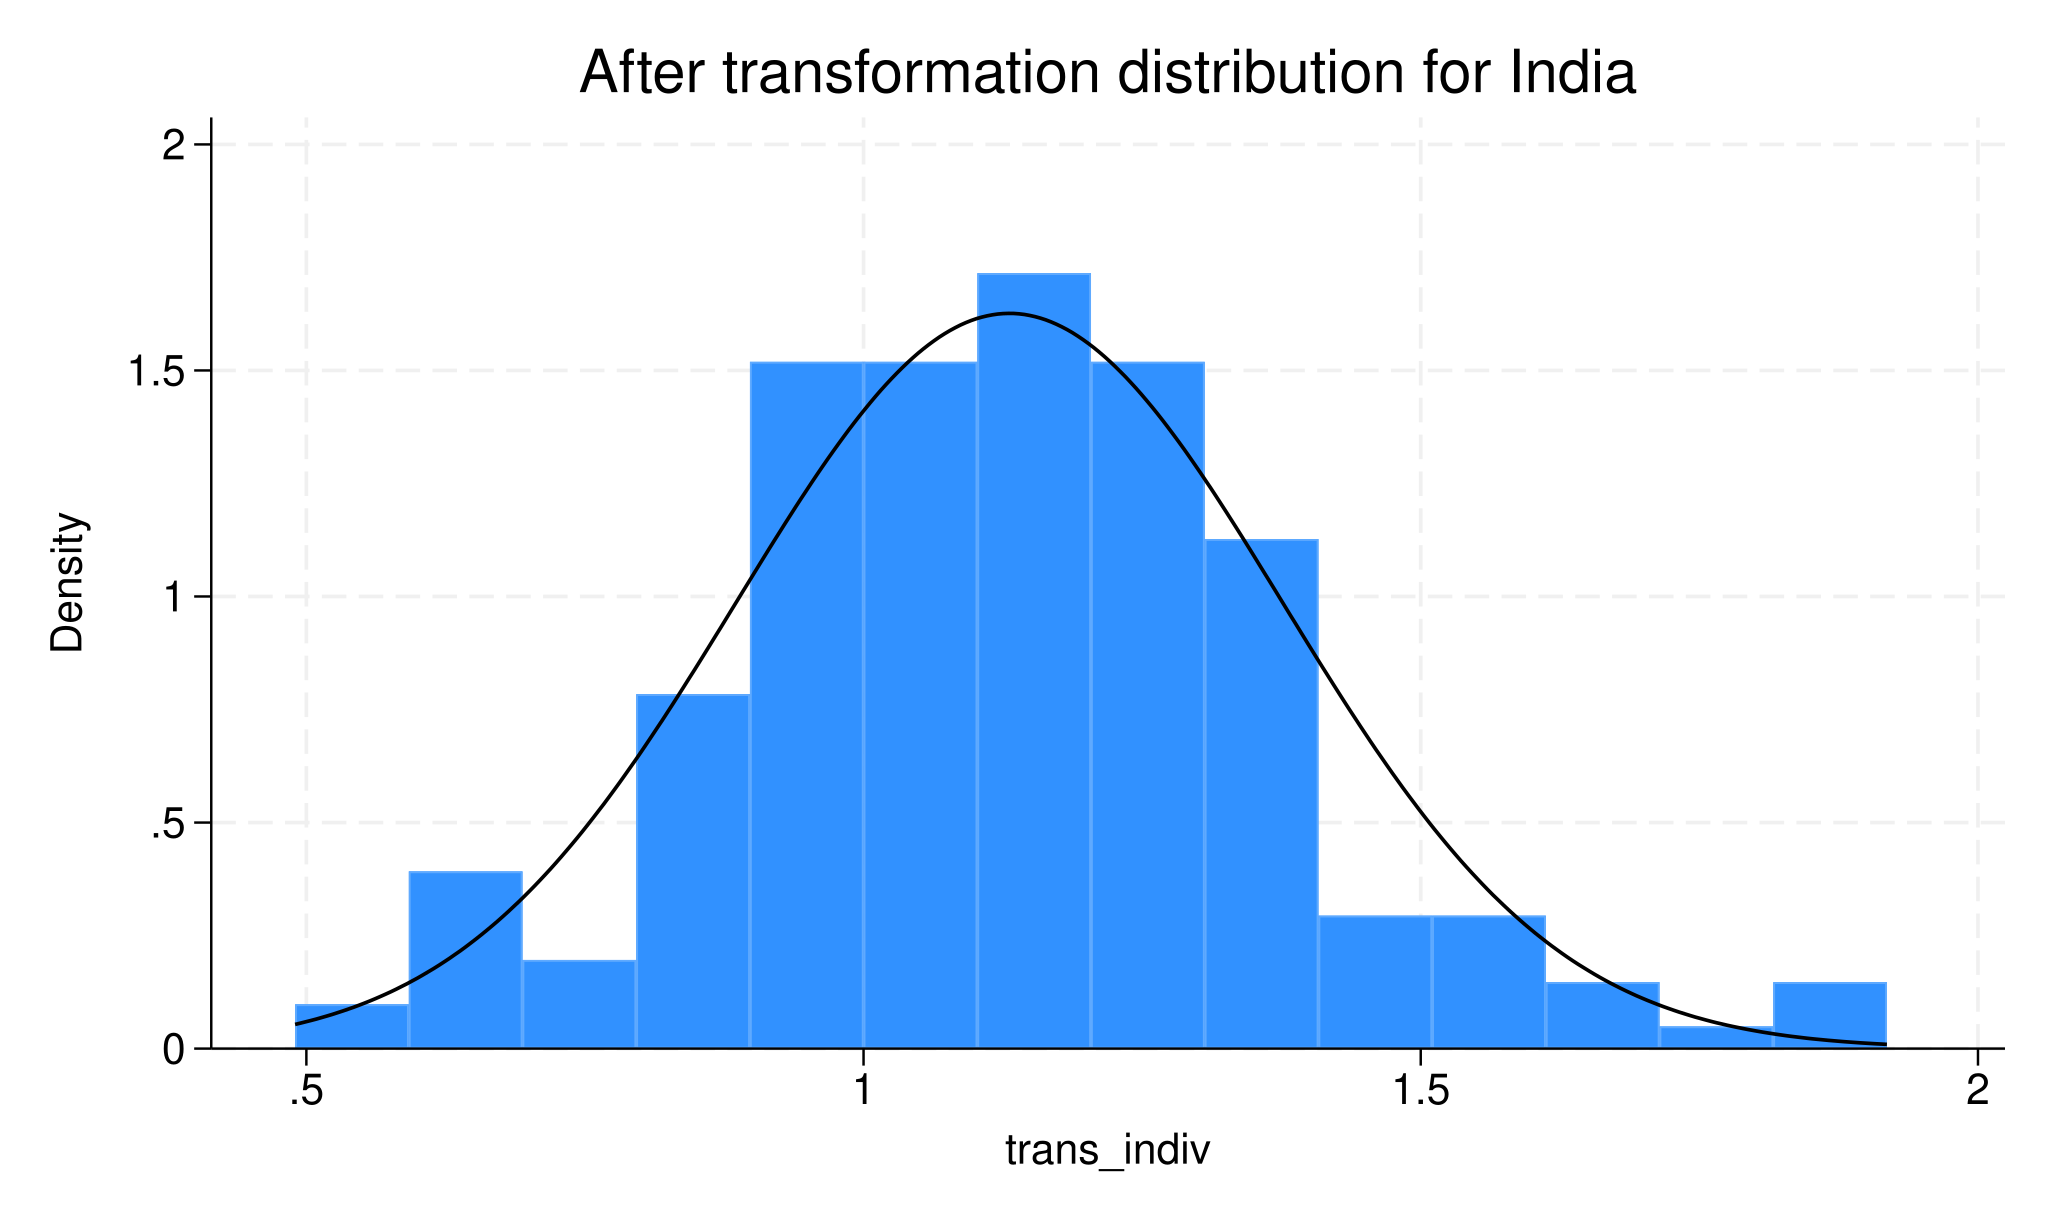

In [62]:
%%stata
hist trans_indiv if country==2, normal title("After transformation distribution for India")

##### Confirm the outliers presence and influence

In [ ]:
%%stata
drop p75 iqrange extr_values_transf outliers_trans
*Confirming outlier presence within a population which undergone a transformation (`sqrt in this case`) should be separately examined from actually telling whether there is a disturbance steaming from these outliers
*Therefore, we need to recalculate the decision rule adjusted to the transformed distribution
bysort country, sort: egen p75 = pctile(trans_indiv), p(75)
bysort country, sort: egen iqrange = iqr(trans_indiv)
gen extr_values_transf = p75 + iqrange*4

list country id trans_indiv if trans_indiv>=extr_values_transf & trans_indiv <.

* confirming outliers presence by using z score transformation
drop z_spain_trans z_india_trans
egen z_spain_trans = std(trans_indiv) if country==1
egen z_india_trans = std(trans_indiv) if country==2

gen outliers_trans = 0
replace outliers_trans =1 if abs(z_spain_trans) >3 & z_spain_trans~=. 
replace outliers_trans =1 if abs(z_india_trans) >3 & z_india_trans~=.

list country id z_spain_trans z_india_trans if outliers_trans==1


. drop p75 iqrange extr_values_transf outliers_trans

. *Confirming outlier presence within a population which undergone a transforma
> tion (`sqrt in this case`) should be separately examined from actually tellin
> g whether there is a disturbance steaming from these outliers
. *Therefore, we need to recalculate the decision rule adjusted to the transfor
> med distribution
. bysort country, sort: egen p75 = pctile(trans_indiv), p(75)

. bysort country, sort: egen iqrange = iqr(trans_indiv)

. gen extr_values_transf = p75 + iqrange*4

. 
. list country id trans_indiv if trans_indiv>=extr_values_transf & trans_indiv 
> <.

     +---------------------------+
     | country     id   trans_~v |
     |---------------------------|
400. |       .   1178   .4582576 |
     +---------------------------+

. 
. * confirming outliers presence by using z score transformation
. drop z_spain_trans z_india_trans

. egen z_spain_trans = std(trans_indiv) if country==1
(203 missing values generated)

. e